# Exploratory Data Analysis of Netflix Titles Dataset

This notebook will perform exploratory data analysis on the Netflix titles dataset.

Goals:
- To understand dataset structure
- Analyze content distribution
- Identify trends in Netflix content

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Overview

In [15]:
df = pd.read_csv("../data/dataset.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [16]:
df.shape

(8807, 12)

In [19]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [21]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## Missing Values Analysis

In [24]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Text(0.5, 1.0, 'Missing Values Heatmap')

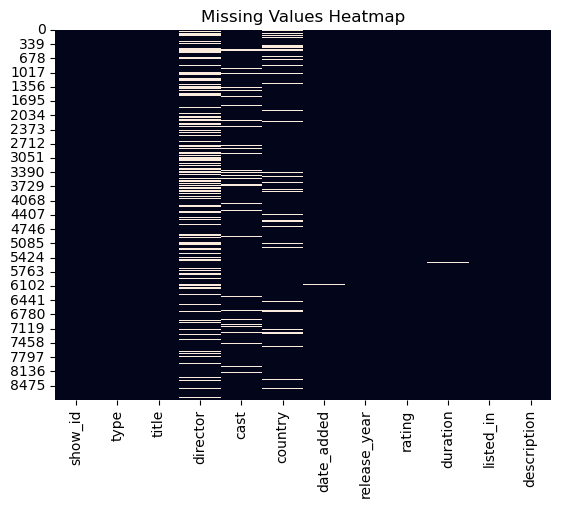

In [25]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")

## Data Cleaning

In [31]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df = df.dropna(subset=['date_added'])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna('Unknown')

In [33]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## PLOTS

Text(0.5, 1.0, 'Movies vs TV Shows on Netflix')

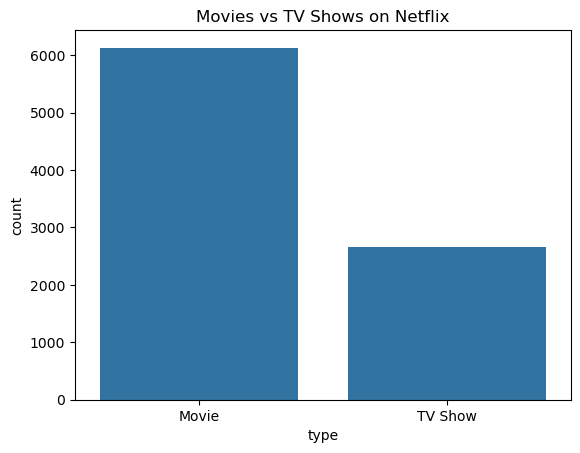

In [34]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows on Netflix")

### Movies vs TV Shows

Observation:
Movies significantly outnumber TV Shows in the dataset.

Insight:
Netflix's catalog historically focused more on movies than serialized content.

Text(0.5, 1.0, 'Top Countries Producing Netflix Content')

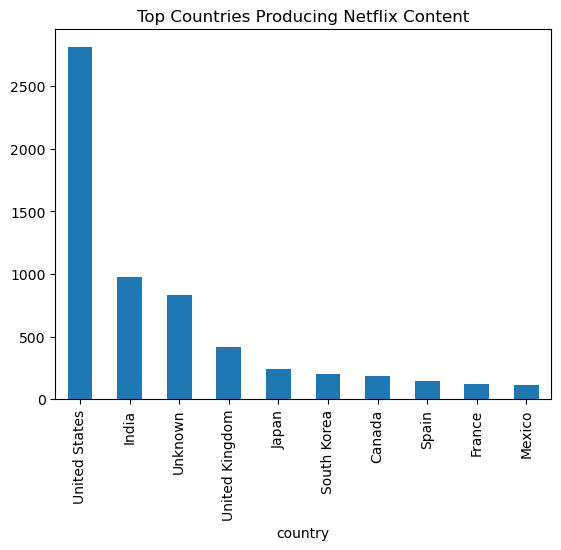

In [35]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')
plt.title("Top Countries Producing Netflix Content")

### Top Countries Producing Netflix Content

Observation: USA produces the most content on Netflix.

Insight: Reflects dominance of the American film industry in the global streaming content platform.

Text(0.5, 1.0, 'Content Growth Over Time')

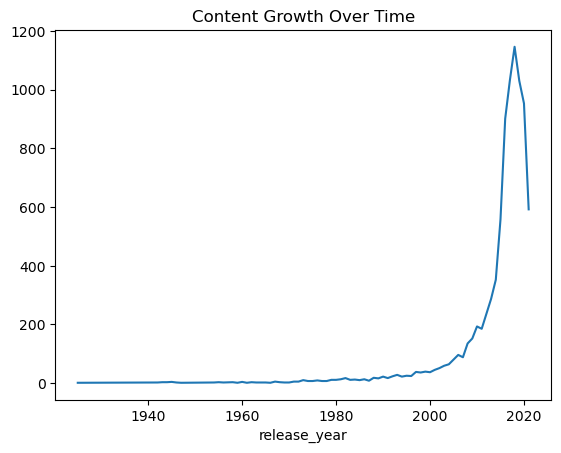

In [39]:
df['release_year'].value_counts().sort_index().plot()

plt.title("Content Growth Over Time")

### Content Growth Over Time

Observation: The number of content significantly increased after all 2015 and reached it's all time peak in and around 2019-20.

Insights: Demand for global streaming services were at an all time high.

Text(0.5, 1.0, 'Content Rating Distribution')

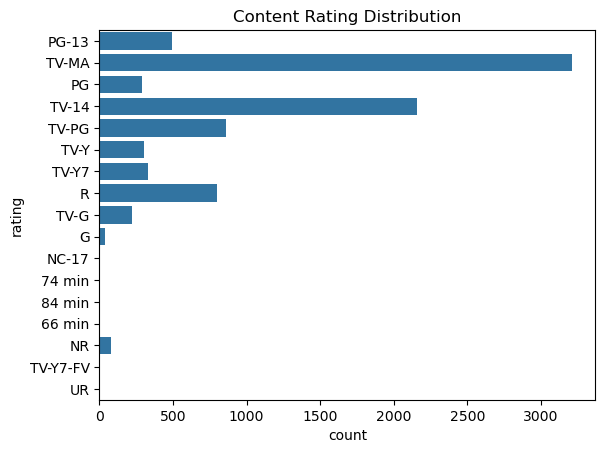

In [40]:
sns.countplot(y='rating', data=df)
plt.title("Content Rating Distribution")

### Content Rating Distribution

Observation: TV-MA is the most common rating, followed by TV-14 and TV-PG.

Insight: This shows that Netflix focuses more on adult and young adult audiences.

Text(0.5, 1.0, 'Top Genres')

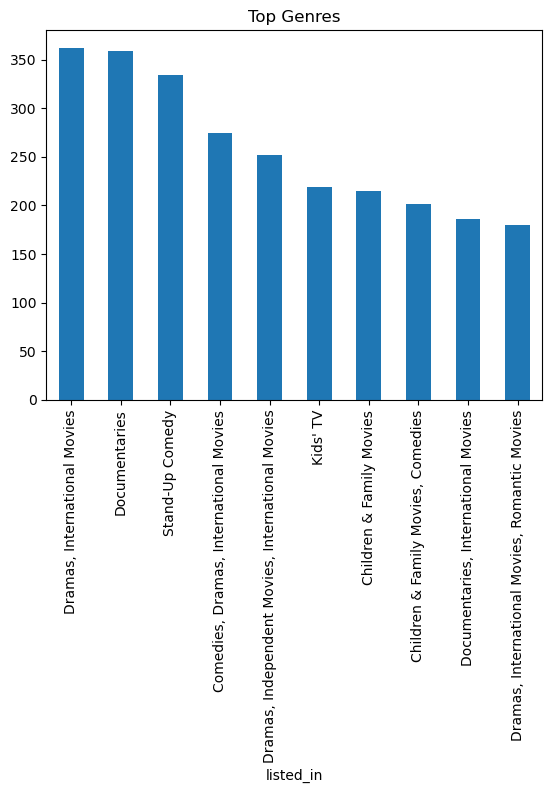

In [49]:
df['listed_in'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")

### Top Genres

Observation:
Dramas and International Movies appear more frequently in the Netflix catalog.

Insight:
The high presence of International Movies indicates Netflix’s focus on expanding its global content and catering to audiences across regions.

Text(0.5, 1.0, 'Correlation Matrix')

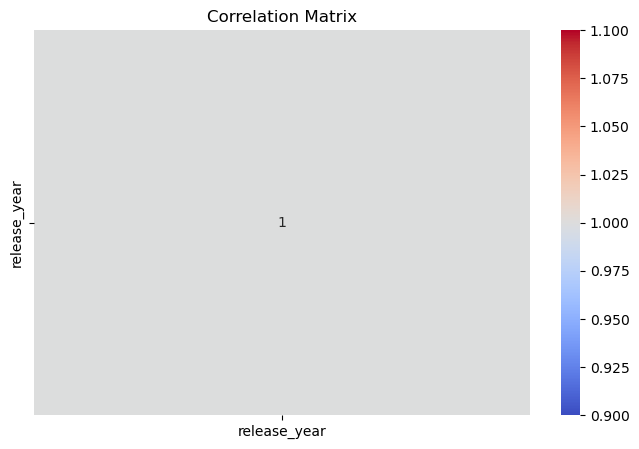

In [46]:
numeric_cols = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,5))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

### Correlation Analysis

Observation:
The dataset contains only one numerical column "release_year".

Insight:
Since correlation analysis requires multiple numerical variables, the correlation matrix does not provide meaningful insights for this dataset.

## Key Insights

1. Movies dominate Netflix’s catalog compared to TV Shows.
2. The United States produces the highest number of titles on Netflix.
3. Netflix content increased rapidly after 2015, reflecting global expansion.
4. TV-MA and TV-14 are the most common ratings, indicating a focus on a more mature audiences.
5. Dramas and International Movies appear most frequently in the Netflix catalog.

## Conclusion

This exploratory data analysis revealed several trends in Netflix’s catalog. 
The platform contains a large number of movies, with the United States being the largest content producer. 
Content production increased significantly after 2015, coinciding with Netflix's global expansion and investment in original programming. 
The catalog largely targets mature audiences and includes a wide range of international content.